## 1. Creating Dataset

In [ ]:
# Run this once at the start of your Colab session
#!pip install "numpy<1.25" numba librosa resampy soundfile

In [ ]:
try:
    # mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/GithubProject/bioacoustic-detection
except:
    pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GithubProject/bioacoustic-detection


In [ ]:
import sys
import os

# 1. Define the path to your project folder
project_path = '/content/drive/MyDrive/GithubProject/bioacoustic-detection'

# 2. Add the 'src' directory to sys.path
sys.path.append(os.path.join(project_path, 'src'))

# 3. Move the working directory to your project folder
# This makes sure relative paths for JSON/Audio files work!
os.chdir(project_path)

In [ ]:
# add code o avoid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
!pip install resampy

In [ ]:
#import sys, os

from data_process.preprocessing import *
from training.train_helper import *

Parameter,Current Value,Recommended Value,Reason
Downsample Rate,4800 Hz,8000 Hz,Standard for low-freq bioacoustics; gives a 4kHz Nyquist.
Lowpass Cutoff,2000 Hz,3500 Hz,Captures all Gibbon harmonics without aliasing.
Nyquist Rate,2400 Hz,4000 Hz,Matches the new downsample rate.

In [ ]:
species_folder = '/content/drive/MyDrive/GithubProject/bioacoustic-detection' # Should contain /Audio and /Annotations
lowpass_cutoff = 3500 #2000 # Cutt off for low pass filter
downsample_rate = 8000#4800 # Frequency to downsample to
nyquist_rate = 4000 # Nyquist rate (half of sampling rate)
segment_duration = 4 # how long should a segment be
positive_class = ['gibbon'] # which labels should be bundled together for the positive  class
background_class = ['no-gibbon'] # which labels should be bundled together for the negative  class
file_type = 'svl'
audio_extension = '.wav'
n_fft = 1024 # Hann window length
hop_length = 256 # Sepctrogram hop size
n_mels = 128 # Spectrogram number of mells
f_min = 400 # Spectrogram, minimum frequency for call
f_max = 4000 # Spectrogram, maximum frequency for call
save_results_folder = 'Saved_Data'

In [ ]:
pre_pro = preprocessing(species_folder,
                        lowpass_cutoff,
                        downsample_rate,
                        nyquist_rate,
                        segment_duration,
                        positive_class,
                        background_class,
                        n_fft,
                        hop_length,
                        n_mels,
                        f_min,
                        f_max,
                        file_type,
                        audio_extension
                    )

In [ ]:
X, Y = pre_pro.create_dataset(True)

Processing: HGSM3AB_0+1_20160303_060100
Processing: HGSM3AB_0+1_20160305_055900
Processing: HGSM3AB_0+1_20160317_055000
Processing: HGSM3AB_0+1_20160331_053800
Processing: HGSM3AC_0+1_20150716_051400
Processing: HGSM3AC_0+1_20150717_051400
Processing: HGSM3AC_0+1_20150807_052200
Processing: HGSM3C_0+1_20150805_052100
Processing: HGSM3C_0+1_20150807_052200
Processing: HGSM3C_0+1_20150812_052300


In [ ]:
## check distrubution of classes
pre_pro.check_distribution(Y)

{'gibbon': np.int64(1929), 'no-gibbon': np.int64(1746)}

In [ ]:
# Save data to pickle file
pre_pro.save_spec_data_to_pickle(X, Y)

In [ ]:
# Load data from pickle file
X_S, Y_S = pre_pro.load_spec_data_from_pickle()

In [ ]:
# check shape of the imnputs
X_S.shape, Y_S.shape

((3675, 128, 126), (3675,))

In [ ]:
# Check data distribution
pre_pro.check_distribution(Y_S)

{'gibbon': np.int64(1929), 'no-gibbon': np.int64(1746)}

In [ ]:
# create function to plot random examples of spectrograms from dataset
import random
import matplotlib.pyplot as plt
def plot_random_spec_from_dataset(X: Array, Y: Array, num_examples: int = 5) -> None:
    indices = random.sample(range(X.shape[0]), num_examples)
    plt.figure(figsize=(5, 3 * num_examples))
    for i, idx in enumerate(indices):
        plt.subplot(num_examples, 1, i + 1)
        plt.imshow(X_S[idx], aspect='auto', origin='lower', cmap='magma')
        plt.title(f"Label: {Y_S[idx]}")
        plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

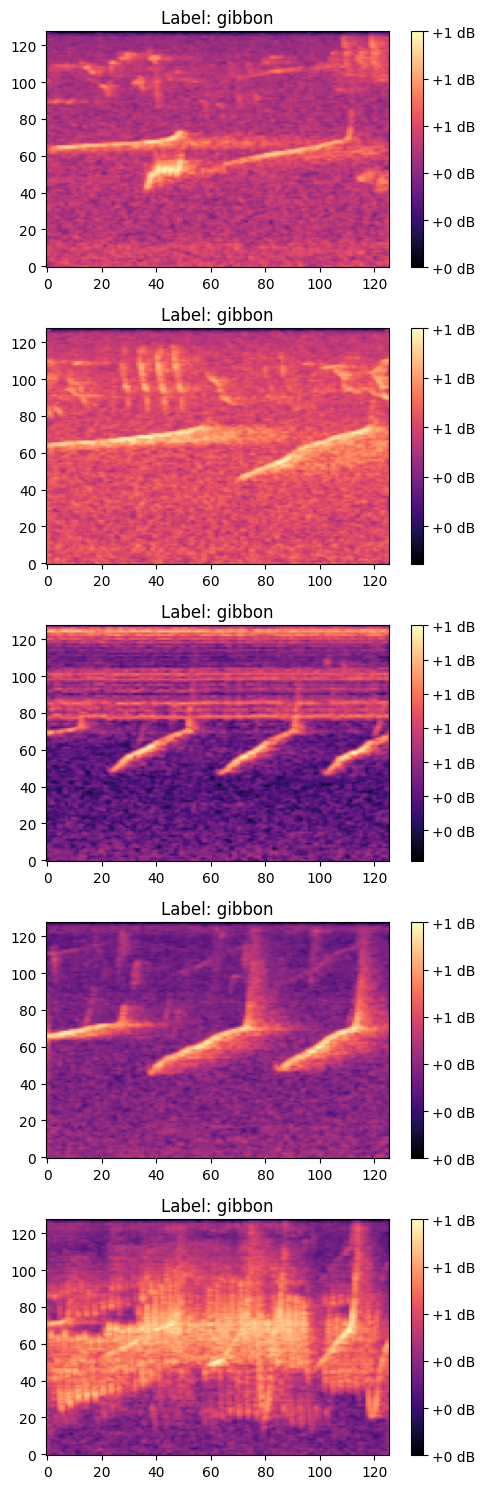

In [ ]:
plot_random_spec_from_dataset(X_S, Y_S, num_examples=5)

## 2. Training

In [ ]:
## Config
species_key= 'gibbon_params'
model_name = 'baseline_cnn'
number_of_run = 1
mod_train = train_helper(species_folder)

In [ ]:
X_S.shape

(3675, 128, 126)

Original split shapes
Training__:  (2940, 128, 126, 1)
Validation:  (735, 128, 126, 1)
Presence: 1393, Absence: 1547
Augmenting 'no-gibbon' by 154
Shapes (after augmentation):
X_calls_train (3094, 128, 126, 1)
X_calls_test (735, 128, 126, 1)
y_train (3094, 2)
y_test (735, 2)
Training distribution: {np.int64(0): np.int64(1547), np.int64(1): np.int64(1547)}


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,864,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,957,762 (30.36 MB)

 Trainable params: 7,957,762 (30.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10

Epoch 1: val_loss improved from inf to 0.71030, saving model to Saved_weights/baseline_cnn_20260127_075502_best.keras
25/25 - 17s - 685ms/step - accuracy: 0.6160 - loss: 1.9204 - val_accuracy: 0.8639 - val_loss: 0.7103 - learning_rate: 1.0000e-03
Epoch 2/10

Epoch 2: val_loss improved from 0.71030 to 0.30767, saving model to Saved_weights/baseline_cnn_20260127_075502_best.keras
25/25 - 7s - 284ms/step - accuracy: 0.8672 - loss: 0.4922 - val_accuracy: 0.9143 - val_loss: 0.3077 - learning_rate: 1.0000e-03
Epoch 3/10

Epoch 3: val_loss improved from 0.30767 to 0.18502, saving model to Saved_weights/baseline_cnn_20260127_075502_best.keras
25/25 - 2s - 94ms/step - accuracy: 0.9541 - loss: 0.2406 - val_accuracy: 0.9619 - val_loss: 0.1850 - learning_rate: 1.0000e-03
Epoch 4/10

Epoch 4: val_loss improved from 0.18502 to 0.14336, saving model to Saved_weights/baseline_cnn_20260127_075502_best.keras
25/25 - 2s - 84ms/step - accuracy: 0.9680 - loss: 0.1722 - val_accuracy: 0.9782 - va

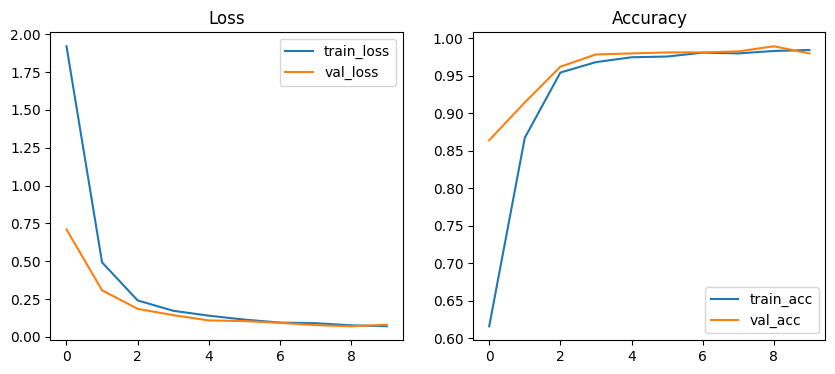

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


NameError: name 'confusion_matrix' is not defined

In [ ]:
mod_train.train(X_S, Y_S, species_key, model_name,1)